# Explore the bee microbiome use case

This notebook analyzes MAGs for the macroalgal microbiome use case.

**Inputs**: data in `../data/bee-use-case/data/`:
- `drep.csv`: dRep clustering output
- `checkm2.tsv`: CheckM2 quality assessment
- `gtdb.tsv`: GTDB taxonomy classification
- `quast.tsv`: QUAST assembly statistics
- `bakta.tsv`: BAKTA genome annotation

**Outputs**
- Plots: `../results/bee-use-case/`

In [88]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib import colors as mcolors


import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str((Path.cwd() / "bin").resolve()))
sys.path.insert(0, str(Path.cwd().resolve()))

from helpers import (
    load_dfs,
    compute_print_stats,
    explore_species_level_clusters_all,
    compute_taxo_classification_summary,
    get_all_taxo_levels,
    get_bakta_annot_df,
    get_kegg_path_df,
    get_relative_abund_taxo_levels,
    print_stats,
    resolve_uc_path,
)

In [89]:
uc_name = "bee-gut"

metadata_df, reps_df, coverage_df = load_dfs(uc_name)
data_dp, result_dp = resolve_uc_path(uc_name)

In [90]:
expert_evaluation_fp = data_dp / "expert_evaluation.xlsx"
df_expert = pd.read_excel(expert_evaluation_fp)

# Quick overview
print(f"Rows: {len(df_expert)}")
print(f"Columns: {df_expert.shape[1]}")

Rows: 48
Columns: 22


In [91]:
sample_order = [
    "C1", "C2", "C3",
    "P1", "P2", "P3",
    "T1", "T2", "T3",
    "TP1", "TP2", "TP3",
    "N1", "N2", "N3",
    "NP1", "NP2", "NP3",
    "NT1", "NT2", "NT3",
]
metadata_df["Replicate"] = metadata_df["Replicate"].astype(str).str.replace(r"\s+Replicate", "", regex=True)

In [92]:
# WARNING: high percentage of unmapped
print("Percentage of unmapped reads for coverage")
print_stats(coverage_df.query("Genome == 'unmapped'").drop(columns="Genome").T.describe())

Percentage of unmapped reads for coverage
738: 3.92 ± 1.48, Median: 3.55, IQR: 2.65-4.53, Range: 2.27-7.33


# Quality

In [93]:
read_numbers = {
    "SRR24759596": 28.0,
    "SRR24759597": 18.1,
    "SRR24759598": 43.9,
    "SRR24759599": 55.3,
    "SRR24759600": 35.8,
    "SRR24759601": 11.9,
    "SRR24759602": 18.6,
    "SRR24759603": 32.0,
    "SRR24759604": 42.5,
    "SRR24759605": 48.7,
    "SRR24759606": 45.6,
    "SRR24759607": 7.8,
    "SRR24759608": 44.7,
    "SRR24759609": 45.8,
    "SRR24759610": 48.0,
    "SRR24759611": 42.1,
    "SRR24759612": 32.6,
    "SRR24759613": 42.3,
    "SRR24759614": 40.4,
    "SRR24759615": 43.6,
    "SRR24759616": 42.8
}
read_numbers_df = pd.DataFrame.from_dict(read_numbers, orient="index", columns=["Read numbers (M)"])
print_stats(read_numbers_df.describe())

Read numbers (M): 36.69 ± 12.90, Median: 42.30, IQR: 32.00-44.70, Range: 7.80-55.30


In [94]:
print(f"Total number of MAGs: {reps_df['Cluster members'].sum()}")
print(f"Total number of species-level clusters: {reps_df.shape[0]}")

Total number of MAGs: 1408
Total number of species-level clusters: 738


In [95]:
explore_species_level_clusters_all(reps_df)

Species-level clusters with no contamination threshold
Total number: 738.0
Cluster members: 1.91 ± 3.28, Median: 1.00, IQR: 1.00-1.00, Range: 1.00-31.00
Contamination: 1.13 ± 1.90, Median: 0.30, IQR: 0.06-1.18, Range: 0.00-9.97
Completeness: 17.93 ± 20.86, Median: 10.50, IQR: 7.70-16.80, Range: 2.20-100.00
Total length: 0.57 ± 0.65, Median: 0.34, IQR: 0.23-0.56, Range: 0.05-5.48

Species-level clusters with contamination < 5%
Total number: 693.0
Cluster members: 1.92 ± 3.25, Median: 1.00, IQR: 1.00-1.00, Range: 1.00-31.00
Contamination: 0.74 ± 1.07, Median: 0.27, IQR: 0.05-0.89, Range: 0.00-4.94
Completeness: 16.73 ± 20.36, Median: 10.20, IQR: 7.60-14.70, Range: 2.20-100.00
Total length: 0.54 ± 0.64, Median: 0.33, IQR: 0.23-0.54, Range: 0.05-5.48

Species-level clusters with contamination < 10%
Total number: 738.0
Cluster members: 1.91 ± 3.28, Median: 1.00, IQR: 1.00-1.00, Range: 1.00-31.00
Contamination: 1.13 ± 1.90, Median: 0.30, IQR: 0.06-1.18, Range: 0.00-9.97
Completeness: 17.93 ±

# Clusters given Bowers et al / MIMAG classification

## HQ: High-quality species-level clusters (contamination < 5% and completeness > 90%)

In [96]:
hq_df = reps_df.query("Contamination < 5 and Completeness > 90")
compute_print_stats(hq_df) 

Total number: 25.0
Cluster members: 10.88 ± 8.76, Median: 11.00, IQR: 3.00-18.00, Range: 1.00-31.00
Contamination: 0.86 ± 0.92, Median: 0.54, IQR: 0.16-1.25, Range: 0.03-3.39
Completeness: 98.57 ± 2.44, Median: 99.80, IQR: 98.40-100.00, Range: 91.40-100.00
Total length: 2.90 ± 1.12, Median: 2.76, IQR: 2.14-3.48, Range: 1.26-5.48


### Taxonomy

In [97]:
compute_taxo_classification_summary(hq_df)

,Unclassified clusters,Classified clusters,Unclassified clusters %,Classified clusters %
Domain,25,0,100.0,0.0
Phylum,25,0,100.0,0.0
Class,25,0,100.0,0.0
Order,25,0,100.0,0.0
Family,25,0,100.0,0.0
Genus,25,0,100.0,0.0
Species,3,22,12.0,88.0


In [98]:
hq_taxo_levels = get_all_taxo_levels(hq_df)


Level: Domain


,Cluster,Cluster %,Total MAG count
Domain,,,
unclassified,25.0,100.0,272.0
TOTAL,25.0,100.0,272.0



Level: Phylum


,Cluster,Cluster %,Total MAG count
Phylum,,,
unclassified,25.0,100.0,272.0
TOTAL,25.0,100.0,272.0



Level: Class


...

,Cluster,Cluster %,Total MAG count
Family,,,
unclassified,25.0,100.0,272.0
TOTAL,25.0,100.0,272.0



Level: Genus


,Cluster,Cluster %,Total MAG count
Genus,,,
unclassified,25.0,100.0,272.0
TOTAL,25.0,100.0,272.0



Level: Species


,Cluster,Cluster %,Total MAG count
Species,,,
Bombiscardovia coryneforme,1.0,4.0,31.0
Snodgrassella alvi,1.0,4.0,27.0
Fructobacillus fructosus,1.0,4.0,21.0
Apilactobacillus kunkeei_C,1.0,4.0,21.0
Frischella perrara,1.0,4.0,21.0
Lactobacillus helsingborgensis,1.0,4.0,18.0
Apilactobacillus kunkeei,1.0,4.0,18.0
unclassified,3.0,12.0,17.0
Proteus mirabilis,1.0,4.0,15.0


### Relative abundance

In [99]:
hq_relative_abund_df = get_relative_abund_taxo_levels(hq_df, coverage_df)

Unmapped reads: 97.99 ± 0.63, Median: 98.04, IQR: 97.69-98.47, Range: 96.38-98.86
Mapped reads: 2.01 ± 0.63, Median: 1.96, IQR: 1.53-2.31, Range: 1.14-3.62

Level: Family


,count,mean,std,min,25%,50%,75%,max
Family,,,,,,,,
unclassified,21.0,100.0,1.230696e-14,100.0,100.0,100.0,100.0,100.0



Level: Genus


,count,mean,std,min,25%,50%,75%,max
Genus,,,,,,,,
unclassified,21.0,100.0,1.230696e-14,100.0,100.0,100.0,100.0,100.0



Level: Species


,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Bombiscardovia coryneforme,21.0,14.834319,5.813520,4.520713,10.321686,15.101173,20.735697,26.198460
Snodgrassella alvi,21.0,13.450944,6.529704,2.563699,8.228466,12.253934,17.021209,25.000389
Frischella perrara,21.0,13.337759,7.381081,1.794902,5.806258,15.555865,18.884089,26.537865
Apilactobacillus kunkeei_C,21.0,12.417001,6.396346,4.386389,6.799073,11.726097,16.231213,26.686901
Proteus mirabilis,21.0,9.169647,9.971945,0.000000,0.984134,8.560328,13.520202,38.845161
Apilactobacillus kunkeei,21.0,7.116151,3.420425,2.780449,4.431025,6.174900,8.685110,16.257300
Fructobacillus fructosus,21.0,4.730643,2.619312,1.753222,2.454262,4.510225,5.245008,11.443680
unclassified,21.0,4.127854,6.281151,0.000000,1.321532,1.595972,2.891076,22.520844
Lactobacillus helsingborgensis,21.0,3.693691,3.448845,0.569242,1.226562,2.258792,5.386091,13.069713


### Functions

In [100]:
print_stats(get_bakta_annot_df(hq_df).describe())

CDSs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
CRISPR arrays: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
gaps: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
hypotheticals: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
ncRNA regions: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
ncRNAs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
oriCs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
oriTs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
oriVs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
pseudogenes: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
rRNAs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
sORFs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
signal peptides: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
tRNAs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
tmRNAs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan


In [101]:
get_kegg_path_df(hq_df)

Before removing rows and columns with only zeros:
Clusters: 25
KEGG modules: 319

After removing rows and columns with only zeros:
Clusters: 25
KEGG modules: 296

KEGG modules: 171.72 ± 37.18, Median: 178.00, IQR: 146.00-196.00, Range: 103.00-233.00


,3-Hydroxypropionate bi-cycle,ADP-L-glycero-D-manno-heptose biosynthesis,"Acetyl-CoA pathway, CO2 => acetyl-CoA",Acylglycerol degradation,"Adenine ribonucleotide biosynthesis, IMP => ADP,ATP","Adenine ribonucleotide degradation, AMP => Urate","Aerobactin biosynthesis, lysine => aerobactin","Anammox, nitrite + ammonia => nitrogen","Anthranilate degradation, anthranilate => catechol","Arginine biosynthesis, glutamate => acetylcitrulline => arginine",...,"Vancomycin resistance, D-Ala-D-Lac type","Vancomycin resistance, D-Ala-D-Ser type","Vibrio cholerae pathogenicity signature, cholera toxins","Xanthomonas spp. pathogenicity signature, T3SS and effectors","Xylene degradation, xylene => methylbenzoate","beta-Carotene biosynthesis, GGAP => beta-carotene","beta-Lactam resistance, Bla system",beta-Oxidation,"beta-Oxidation, acyl-CoA synthesis",dTDP-L-rhamnose biosynthesis
0,16.67,100.0,0.00,0.0,100.0,66.67,0.0,0.00,0.00,100.00,...,25.00,0.0,0.00,6.82,0.00,0.00,0.00,100.00,100.0,83.33
1,16.67,100.0,0.00,50.0,100.0,66.67,25.0,0.00,0.00,85.71,...,0.00,0.0,0.00,5.68,0.00,0.00,0.00,100.00,100.0,50.00
2,16.67,80.0,0.00,0.0,100.0,66.67,0.0,0.00,0.00,100.00,...,25.00,0.0,0.00,0.00,0.00,0.00,33.33,0.00,100.0,100.00
3,16.67,100.0,0.00,0.0,100.0,66.67,0.0,0.00,25.00,100.00,...,25.00,0.0,0.00,6.82,0.00,0.00,0.00,100.00,100.0,83.33
4,16.67,80.0,0.00,50.0,100.0,66.67,0.0,0.00,0.00,100.00,...,0.00,0.0,0.00,0.00,0.00,0.00,0.00,100.00,100.0,100.00
5,16.67,80.0,0.00,50.0,100.0,66.67,0.0,0.00,0.00,100.00,...,25.00,0.0,16.67,0.00,0.00,0.00,0.00,66.67,100.0,100.00
6,5.56,100.0,0.00,50.0,75.0,50.00,0.0,0.00,0.00,100.00,...,25.00,0.0,0.00,1.14,0.00,0.00,0.00,0.00,0.0,0.00
7,11.11,0.0,0.00,0.0,50.0,77.78,0.0,0.00,0.00,14.29,...,25.00,0.0,0.00,1.14,0.00,0.00,33.33,0.00,0.0,33.33
8,12.96,0.0,0.00,0.0,75.0,16.67,0.0,0.00,0.00,57.14,...,0.00,0.0,0.00,0.00,0.00,0.00,33.33,0.00,100.0,0.00
9,22.22,100.0,0.00,0.0,100.0,66.67,0.0,0.00,25.00,100.00,...,0.00,0.0,0.00,0.00,33.33,0.00,33.33,100.00,100.0,83.33


## MQ: Medium-quality species-level clusters (contamination < 10% and completeness > 50%)


In [102]:
mq_df = reps_df.query("Contamination < 10 and Completeness > 50")
display(mq_df.iloc[:, :25])
compute_print_stats(mq_df) 

,MAG,Domain,Phylum,Class,Order,Family,Genus,Species,Cluster members,Completeness,...,GC (%),L50,L90,Largest contig,N50,N90,Total length,Total length (>= 0 bp),Total length (>= 1000 bp),auN
0,SRR24759603_binette_bin1,unclassified,unclassified,unclassified,unclassified,unclassified,unclassified,Providencia alcalifaciens,4,100.0,...,41.84,6.0,13.0,506402.0,261870.0,132919.0,3861557.0,3861557.0,3861557.0,283861.3
1,SRR24759615_binette_bin1,unclassified,unclassified,unclassified,unclassified,unclassified,unclassified,Proteus mirabilis,15,100.0,...,38.73,23.0,71.0,127849.0,49487.0,17631.0,3476427.0,3476427.0,3476427.0,55623.8
2,SRR24759600_binette_bin6,unclassified,unclassified,unclassified,unclassified,unclassified,unclassified,Entomomonas moraniae,1,100.0,...,38.07,4.0,14.0,513259.0,285762.0,46381.0,3426966.0,3426966.0,3426966.0,302215.1
3,SRR24759606_binette_bin1,unclassified,unclassified,unclassified,unclassified,unclassified,unclassified,Providencia hangzhouensis,1,100.0,...,40.12,6.0,14.0,645620.0,301940.0,124058.0,4504648.0,4504648.0,4504648.0,332957.4
4,SRR24759606_binette_bin2,unclassified,unclassified,unclassified,unclassified,unclassified,unclassified,Entomomonas sp040391985,7,100.0,...,35.79,5.0,15.0,430480.0,271820.0,76097.0,3260803.0,3260803.0,3260803.0,249663.5
5,SRR24759603_binette_bin2,unclassified,unclassified,unclassified,unclassified,unclassified,unclassified,unclassified,4,100.0,...,39.81,7.0,17.0,347229.0,188039.0,57275.0,3041630.0,3041630.0,3041630.0,181627.2
6,SRR24759597_binette_bin1,unclassified,unclassified,unclassified,unclassified,unclassified,unclassified,Frischella perrara,21,100.0,...,34.00,16.0,55.0,151911.0,33844.0,9767.0,2142574.0,2142574.0,2142574.0,54116.7
7,SRR24759600_binette_bin3,unclassified,unclassified,unclassified,unclassified,unclassified,unclassified,Schnuerera sp021655095,3,100.0,...,31.40,37.0,121.0,105510.0,23593.0,7535.0,2758665.0,2758665.0,2758665.0,28461.7
8,SRR24759606_binette_bin3,unclassified,unclassified,unclassified,unclassified,unclassified,unclassified,Apilactobacillus kunkeei_C,21,100.0,...,37.14,22.0,73.0,89870.0,23540.0,5687.0,1535311.0,1535311.0,1535311.0,27390.6
9,SRR24759610_binette_bin1,unclassified,unclassified,unclassified,unclassified,unclassified,unclassified,Klebsiella oxytoca,11,99.9,...,55.49,30.0,88.0,299962.0,57121.0,19335.0,5483319.0,5483319.0,5483319.0,77894.5


Total number: 55.0
Cluster members: 9.13 ± 8.31, Median: 6.00, IQR: 1.50-14.00, Range: 1.00-31.00
Contamination: 2.55 ± 2.71, Median: 1.62, IQR: 0.52-3.34, Range: 0.03-9.55
Completeness: 84.51 ± 15.99, Median: 89.10, IQR: 72.75-99.70, Range: 51.90-100.00
Total length: 2.40 ± 1.05, Median: 2.24, IQR: 1.54-2.97, Range: 0.38-5.48


In [103]:
print(f"Total number of MAGs: {mq_df['Cluster members'].sum()}")
print(f"Percentage with completeness > 90%: {mq_df.query("Completeness > 90").shape[0] / mq_df.shape[0] * 100}")

Total number of MAGs: 502
Percentage with completeness > 90%: 47.27272727272727


In [104]:
print("Species-level clusters with contamination >= 10% and completeness > 50%:")
tmp_df = reps_df.query("Contamination >= 10 and Completeness > 50")
display(tmp_df)
#print(f"Contamination: {tmp_df['Contamination'].iloc[0]}")

Species-level clusters with contamination >= 10% and completeness > 50%:


,MAG,Domain,Phylum,Class,Order,Family,Genus,Species,Cluster members,Completeness,...,"kegg_Xanthomonas spp. pathogenicity signature, T3SS and effectors","kegg_Xylene degradation, xylene => methylbenzoate","kegg_beta-Carotene biosynthesis, GGAP => beta-carotene","kegg_beta-Lactam resistance, Bla system",kegg_beta-Oxidation,"kegg_beta-Oxidation, acyl-CoA synthesis","kegg_beta-Oxidation, peroxisome, VLCFA",kegg_dTDP-L-mycarose biosynthesis,kegg_dTDP-L-oleandrose biosynthesis,kegg_dTDP-L-rhamnose biosynthesis


### Taxonomy

In [105]:
compute_taxo_classification_summary(mq_df)

,Unclassified clusters,Classified clusters,Unclassified clusters %,Classified clusters %
Domain,55,0,100.0,0.0
Phylum,55,0,100.0,0.0
Class,55,0,100.0,0.0
Order,55,0,100.0,0.0
Family,55,0,100.0,0.0
Genus,55,0,100.0,0.0
Species,10,45,18.18,81.82


In [106]:
mq_taxo_levels = get_all_taxo_levels(mq_df)


Level: Domain


,Cluster,Cluster %,Total MAG count
Domain,,,
unclassified,55.0,100.0,502.0
TOTAL,55.0,100.0,502.0



Level: Phylum


,Cluster,Cluster %,Total MAG count
Phylum,,,
unclassified,55.0,100.0,502.0
TOTAL,55.0,100.0,502.0



Level: Class


...

,Cluster,Cluster %,Total MAG count
Family,,,
unclassified,55.0,100.0,502.0
TOTAL,55.0,100.0,502.0



Level: Genus


,Cluster,Cluster %,Total MAG count
Genus,,,
unclassified,55.0,100.0,502.0
TOTAL,55.0,100.0,502.0



Level: Species


,Cluster,Cluster %,Total MAG count
Species,,,
Snodgrassella alvi,2.0,3.636364,39.0
Bombiscardovia coryneforme,1.0,1.818182,31.0
Bartonella_A sp945285915,1.0,1.818182,25.0
Lactobacillus apis,1.0,1.818182,25.0
unclassified,10.0,18.181818,24.0
Apilactobacillus kunkeei_C,1.0,1.818182,21.0
Fructobacillus fructosus,1.0,1.818182,21.0
Frischella perrara,1.0,1.818182,21.0
Bartonella_A apis,1.0,1.818182,21.0


### Relative abundance

In [107]:
coverage_df.sum(axis = 0)

Genome         SRR24759596_binette_bin14SRR24759596_binette_b...
SRR24759596                                           100.000022
SRR24759597                                            99.999999
SRR24759598                                           100.000002
SRR24759599                                           100.000021
SRR24759600                                            99.999989
SRR24759601                                            99.999986
SRR24759602                                            99.999976
SRR24759603                                            99.999993
SRR24759604                                           100.000004
SRR24759605                                            99.999969
SRR24759606                                           100.000002
SRR24759607                                            99.999939
SRR24759608                                            99.999994
SRR24759609                                            99.999994
SRR24759610              

In [108]:
mq_relative_abund_df = get_relative_abund_taxo_levels(mq_df, coverage_df)

Unmapped reads: 94.72 ± 0.74, Median: 94.64, IQR: 94.51-95.21, Range: 93.16-96.14
Mapped reads: 5.28 ± 0.74, Median: 5.36, IQR: 4.79-5.49, Range: 3.86-6.84

Level: Family


,count,mean,std,min,25%,50%,75%,max
Family,,,,,,,,
unclassified,21.0,100.0,1.271057e-14,100.0,100.0,100.0,100.0,100.0



Level: Genus


,count,mean,std,min,25%,50%,75%,max
Genus,,,,,,,,
unclassified,21.0,100.0,1.271057e-14,100.0,100.0,100.0,100.0,100.0



Level: Species


,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Bartonella_A apis,21.0,18.105650,5.827651,7.284061,13.620204,18.639473,22.013584,28.074819
unclassified,21.0,16.024845,4.108555,8.777573,13.323157,15.634861,19.846587,21.699546
Snodgrassella alvi,21.0,8.867582,3.844630,3.174792,6.416765,7.996016,11.145363,16.448275
Bombiscardovia coryneforme,21.0,5.326927,1.832209,2.412764,4.199604,5.518682,6.408748,9.221914
Bartonella_A choladocola,21.0,5.250051,3.358266,0.672405,2.424867,5.188492,7.967951,12.671047
Frischella perrara,21.0,4.904499,2.817486,0.678462,2.626736,5.219337,6.066495,10.078687
Apilactobacillus kunkeei_C,21.0,4.562437,2.329265,1.299992,3.106854,3.590075,5.892711,10.087480
Lactobacillus apis,21.0,4.329794,1.850723,1.931973,2.871670,3.836876,5.796339,8.093410
Bartonella_A sp945285915,21.0,3.941935,1.566374,1.511453,2.970491,3.739962,4.962113,7.708951


In [109]:
run_to_replicate = metadata_df.set_index("Run accession")["Replicate"].to_dict()
mq_relative_abund_df = mq_relative_abund_df.rename(
    columns={
        column: run_to_replicate[column]
        for column in mq_relative_abund_df.columns
        if column.startswith("SRR") and column in run_to_replicate
    }
)

mq_relative_abund_df =mq_relative_abund_df[[*sample_order]]
mq_relative_abund_df.head()

C1        C2  \
Family       Genus        Species                                          
unclassified unclassified Apibacter sp945280365       0.075032  0.119583   
                          Apilactobacillus apinorum   0.190684  2.178975   
                          Apilactobacillus kunkeei    2.663645  3.553617   
                          Apilactobacillus kunkeei_C  3.291922  7.400973   
                          Arsenophonus apicola        0.262888  0.036180   

                                                            C3        P1  \
Family       Genus        Species                                          
unclassified unclassified Apibacter sp945280365       0.703373  0.030755   
                          Apilactobacillus apinorum   0.068438  0.482018   
                          Apilactobacillus kunkeei    2.465819  6.743996   
                          Apilactobacillus kunkeei_C  3.329196  7.349121   
                          Arsenophonus apicola        0.071768  0.000000   

                                                            P2        P3  \
Family       Genus        Species                                          
unclassified unclassified Apibacter sp945280365       0.101581  0.069740   
                          Apilactobacillus apinorum   0.371129  0.043760   
                          Apilactobacillus kunkeei    1.434413  1.555414   
                          Apilactobacillus kunkeei_C  3.537732  1.299992   
                          Arsenophonus apicola        0.090168  0.820017   

                                                            T1         T2  \
Family       Genus        Species                                           
unclassified unclassified Apibacter sp945280365       0.000000   1.160191   
                          Apilactobacillus apinorum   0.131825   0.496549   
                          Apilactobacillus kunkeei    3.109673   4.859930   
                          Apilactobacillus kunkeei_C  4.497512  10.087480   
                          Arsenophonus apicola        0.200614   0.023884   

                                                            T3       TP1  ...  \
Family       Genus        Species                                         ...   
unclassified unclassified Apibacter sp945280365       0.000000  0.080083  ...   
                          Apilactobacillus apinorum   0.000000  0.321215  ...   
                          Apilactobacillus kunkeei    2.196963  1.478870  ...   
                          Apilactobacillus kunkeei_C  1.980078  5.828923  ...   
                          Arsenophonus apicola        0.000000  0.072763  ...   

                                                           TP3        N1  \
Family       Genus        Species                                          
unclassified unclassified Apibacter sp945280365       0.768755  0.075586   
                          Apilactobacillus apinorum   0.077453  0.108966   
                          Apilactobacillus kunkeei    1.360941  1.456672   
                          Apilactobacillus kunkeei_C  3.106854  2.330247   
                          Arsenophonus apicola        0.028059  0.089243   

                                                            N2        N3  \
Family       Genus        Species                                          
unclassified unclassified Apibacter sp945280365       1.084405  1.191696   
                          Apilactobacillus apinorum   1.469223  0.042637   
                          Apilactobacillus kunkeei    2.164611  2.777722   
                          Apilactobacillus kunkeei_C  5.892711  1.449400   
                          Arsenophonus apicola        0.112759  0.000000   

                                                           NP1       NP2  \
Family       Genus        Species                                          
unclassified unclassified Apibacter sp945280365       0.871837  0.269714   
                          Apilactobacillus apinorum   0.064

#### Relative abundance of control data

In [110]:
control_species_abund_df = mq_relative_abund_df[["C1", "C2", "C3"]]
control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False)

count  \
Family       Genus        Species                                     
unclassified unclassified Bartonella_A apis                     3.0   
                          unclassified                          3.0   
                          Snodgrassella alvi                    3.0   
                          Bombiscardovia coryneforme            3.0   
                          Bartonella_A choladocola              3.0   
                          Apilactobacillus kunkeei_C            3.0   
                          Lactobacillus apis                    3.0   
                          Frischella perrara                    3.0   
                          Bartonella_A sp945285915              3.0   
                          Gilliamella apis_A                    3.0   
                          Lactobacillus melliventris            3.0   
                          Apilactobacillus kunkeei              3.0   
                          Lactobacillus helsingborgensis        3.0   
                          Fructobacillus fructosus              3.0   
                          Gilliamella apis                      3.0   
                          Lactobacillus kimbladii               3.0   
                          Klebsiella oxytoca                    3.0   
                          Novisyntrophococcus liquoris          3.0   
                          Gilliamella apicola                   3.0   
                          Gilliamella apicola_N                 3.0   
                          Virgibacillus proomii_B               3.0   
                          Apilactobacillus apinorum             3.0   
                          Bombilactobacillus mellis             3.0   
                          Enterococcus faecalis                 3.0   
                          Gilliamella apicola_R                 3.0   
                          Gilliamella sp946480175               3.0   
                          Proteus mirabilis                     3.0   
                          Apibacter sp945280365                 3.0   
                          Snodgrassella alvi_G                  3.0   
                          Gilliamella sp945271295               3.0   
                          Lactobacillus juensis                 3.0   
                          Arsenophonus apicola                  3.0   
                          Entomomonas sp945283395               3.0   
                          CABMKH01 sp040797625                  3.0   
                          Entomomonas sp040391985               3.0   
                          Novisyntrophococcus fermenticellae    3.0   
                          Morganella sibonii                    3.0   
                          Providencia alcalifaciens             3.0   
                          Providencia rettgeri                  3.0   
                          Entomomonas moraniae                  3.0   
                          Providencia hangzhouensis             3.0   
                          Klebsiella grimontii                  3.0   
                          Serratia ureilytica                   3.0   
                          Lactobacillus panisapium              3.0   
                          Schnuerera sp021655095                3.0   

                                                                   mean  \
Family       Genus        Species                                         
unclassified unclassified Bartonella_A apis                   19.810603   
                          unclassified                        16.625121   
                          Snodgrassella alvi                   7.941078   
                          Bombiscardovia coryneforme           5.865004   
                          Bartonella_A choladocola             5.604903   
                          Apilactobacillus kunkeei_C           4.674030   
                          Lactobacillus apis                   4.540955   
                          Frischella perrara     

In [111]:
#control_species_abund_df.xs("Bartonella_A", level=1, axis=0, drop_level=False).sum(axis=0).describe()

#### Relative abundance of all experimental conditions

In [112]:
print("Proteus mirabilis")
print("Control samples:")
control_species_abund_df = mq_relative_abund_df[["C1", "C2", "C3"]]
display(control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False).xs("Proteus mirabilis", level=2, axis=0, drop_level=False))
print("Infected samples:")
infected_species_abund_df = mq_relative_abund_df[["N1", "N2", "N3"]]
display(infected_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False).xs("Proteus mirabilis", level=2, axis=0, drop_level=False))

Proteus mirabilis
Control samples:


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
unclassified,unclassified,Proteus mirabilis,3.0,0.325345,0.036753,0.286406,0.308302,0.330199,0.344815,0.359431


Infected samples:


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
unclassified,unclassified,Proteus mirabilis,3.0,5.744253,2.688699,3.373595,4.283532,5.19347,6.929583,8.665696


In [113]:
arsenophonus_abund_df = mq_relative_abund_df.xs("Arsenophonus apicola", level=2, axis=0, drop_level=False).T
print(f"Abundance for Arsenophonus apicola in TP2: {arsenophonus_abund_df.loc['TP2'].values[0]}")
print("Abundance for Arsenophonus apicola without TP2 sample: ")
arsenophonus_abund_df.drop(["TP2"]).describe().T

Abundance for Arsenophonus apicola in TP2: 21.714888929317578
Abundance for Arsenophonus apicola without TP2 sample: 


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
unclassified,unclassified,Arsenophonus apicola,20.0,0.108117,0.18286,0.0,0.0,0.072265,0.11104,0.820017


Saved combined figure to: ../results/use-cases/bee-gut/mq_combined_relative_abundance_pca.png


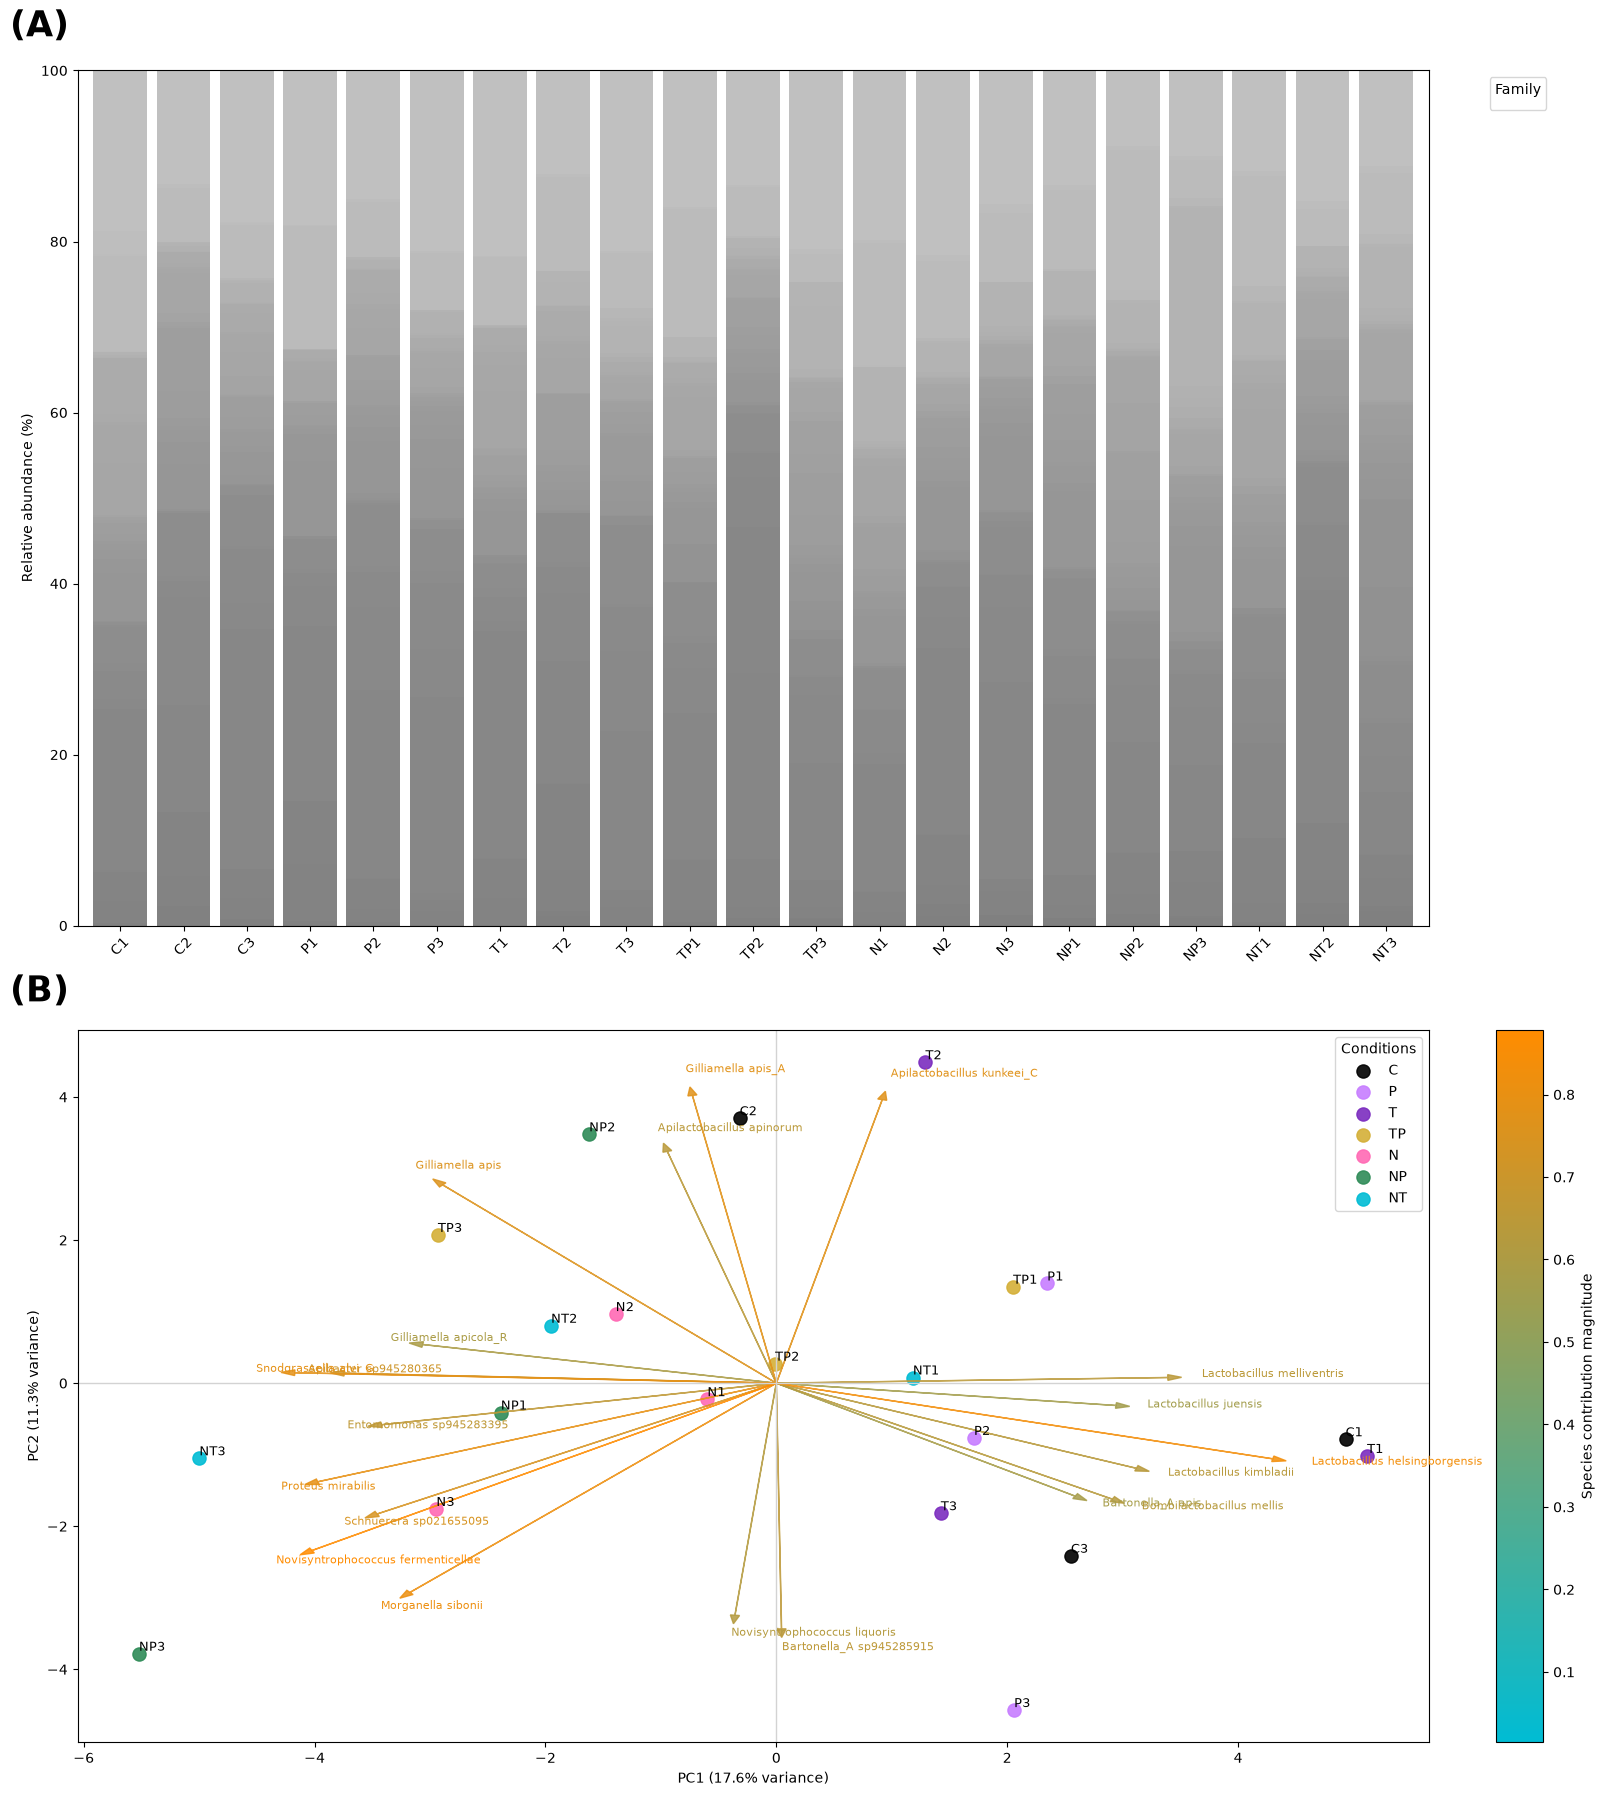

,PC1,PC2,Category
C1,4.931200,-0.784482,C
C2,-0.317487,3.703391,C
C3,2.551966,-2.413828,C
P1,2.346152,1.393064,P
P2,1.712283,-0.765335,P
P3,2.059826,-4.569972,P
T1,5.117781,-1.017594,T
T2,1.291997,4.484962,T
T3,1.424946,-1.819052,T
TP1,2.051294,1.347680,TP


In [114]:
family_colors = {
    "Rhizobiaceae": "sandybrown",  # Bartonellaceae
    "Neisseriaceae": "violet",
    "Enterobacteriaceae": "dodgerblue",  # Orbaceae
    "Lactobacillaceae": "red",
    "Leuconostocaceae": "orange",
    "Bifidobacteriaceae": "limegreen",
    # not in the original paper
    "Pseudomonadaceae": "cyan",
    "Lachnospiraceae": "lightyellow",
    "Weeksellaceae": "brown",
    "Enterococcaceae": "lightcoral",
    "Tepidimicrobiaceae": "lightgreen",
    "Amphibacillaceae": "lightblue",
}

def make_family_shades(base_color, n):
    if n <= 1:
        return [mcolors.to_hex(base_color)]
    base_rgb = np.array(mcolors.to_rgb(base_color))
    white = np.array([1.0, 1.0, 1.0])
    factors = np.linspace(0.0, 0.5, n)
    return [mcolors.to_hex(base_rgb * (1 - f) + white * f) for f in factors]

def make_color_gradient(start_color, end_color, n):
    if n <= 1:
        return [mcolors.to_hex(start_color)]
    start_rgb = np.array(mcolors.to_rgb(start_color))
    end_rgb = np.array(mcolors.to_rgb(end_color))
    factors = np.linspace(0.0, 1.0, n)
    return [mcolors.to_hex(start_rgb * (1 - f) + end_rgb * f) for f in factors]

family_order = list(family_colors.keys())
family_rank = {family: rank for rank, family in enumerate(family_order)}

# Reorder species rows so stacked bars follow the requested family order
index_df = mq_relative_abund_df.index.to_frame(index=False)
index_df["sort_rank"] = index_df["Family"].map(family_rank).fillna(len(family_order)).astype(int)
index_df = index_df.sort_values(["sort_rank", "Family", "Genus", "Species"], kind="stable")
ordered_index = pd.MultiIndex.from_frame(index_df[["Family", "Genus", "Species"]])
species_abund_df_ordered = mq_relative_abund_df.loc[ordered_index]

# Default colors: same family hue, different shade within family
default_color_map = {}
for family_name, group in index_df.groupby("Family", sort=False):
    base_color = family_colors.get(family_name, "gray")
    shades = make_family_shades(base_color, len(group))
    for (_, row), shade in zip(group.iterrows(), shades):
        default_color_map[(row["Family"], row["Genus"], row["Species"])] = shade

# Special overrides requested by user
providencia_count = index_df["Genus"].astype(str).str.lower().str.startswith("providencia").sum()
providencia_shades = iter(make_color_gradient("#c4a484", "#654321", providencia_count))

species_colors = []
for _, row in index_df.iterrows():
    family_name = row["Family"]
    genus_name = str(row["Genus"]).strip().lower()
    species_name = str(row["Species"]).strip().lower()
    key = (row["Family"], row["Genus"], row["Species"])
    if genus_name.startswith("arsenophonus") and species_name == "apicola":
        color = "black"
    elif genus_name.startswith("proteus"):
        color = "#c4a484"  # light brown
    elif genus_name.startswith("providencia"):
        color = next(providencia_shades)
    else:
        color = default_color_map.get(key, family_colors.get(family_name, "gray"))
    species_colors.append(color)

sample_matrix = mq_relative_abund_df.select_dtypes(include=[np.number]).T
scaled_sample_matrix = StandardScaler().fit_transform(sample_matrix)
pca = PCA(n_components=2)
sample_scores = pca.fit_transform(scaled_sample_matrix)
species_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

sample_scores_df = pd.DataFrame(sample_scores, index=sample_matrix.index, columns=["PC1", "PC2"])
sample_scores_df["Category"] = (
    sample_scores_df.index.to_series()
    .str.extract(r"^(NT|NP|TP|C|T|P|N)", expand=False)
    .fillna("Other")
)

category_palette = {
    "C": "#000000",
    "T": "#7b2cbf",
    "P": "#c77dff",
    "N": "#ff69b4",
    "NT": "#00bcd4",
    "NP": "#2e8b57",
    "TP": "#d4af37",
    "Other": "#6c757d",
}

species_contribution = np.linalg.norm(species_loadings, axis=1)
contribution_norm = plt.Normalize(species_contribution.min(), species_contribution.max())
arrow_cmap = LinearSegmentedColormap.from_list("cyan_orange", ["#00bcd4", "#ff8c00"])
arrow_colors = arrow_cmap(contribution_norm(species_contribution))

top_species_idx = np.argsort(species_contribution)[-20:]
score_limit = np.abs(sample_scores_df[["PC1", "PC2"]].to_numpy()).max()
loading_limit = np.abs(species_loadings[top_species_idx]).max()
arrow_scale = 1.0 if loading_limit == 0 else (score_limit / loading_limit) * 0.8

fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(16, 18), gridspec_kw={"height_ratios": [1.2, 1]})

# (A) Relative abundance stacked bars
species_abund_df_ordered.T.plot(
    kind="bar",
    stacked=True,
    ax=ax_a,
    color=species_colors,
    width=0.85,
    legend=False,
)
ax_a.set_ylabel("Relative abundance (%)")
ax_a.set_ylim(0, 100)
ax_a.tick_params(axis="x", rotation=45)
present_families = [family for family in family_order if family in set(index_df["Family"])]
legend_handles = [
    Patch(facecolor=family_colors.get(family, "gray"), label=family)
    for family in present_families
]
right_margin_x = 1.05
ax_a.legend(handles=legend_handles, title="Family", bbox_to_anchor=(right_margin_x-0.01, 1), loc="upper left")
ax_a.text(-0.05, 1.04, "(A)", transform=ax_a.transAxes, fontsize=25, fontweight="bold")

# (B) PCA biplot
for category, frame in sample_scores_df.groupby("Category", sort=False):
    ax_b.scatter(
        frame["PC1"],
        frame["PC2"],
        s=90,
        color=category_palette.get(category, category_palette["Other"]),
        label=category,
        alpha=0.9,
    )
    for sample_name, row in frame.iterrows():
        ax_b.text(row["PC1"], row["PC2"], sample_name, fontsize=9, ha="left", va="bottom")

for idx in top_species_idx:
    species_name = mq_relative_abund_df.index[idx][2]
    x_loading = species_loadings[idx, 0] * arrow_scale
    y_loading = species_loadings[idx, 1] * arrow_scale
    ax_b.arrow(
        0,
        0,
        x_loading,
        y_loading,
        color=arrow_colors[idx],
        alpha=0.85,
        width=0.002,
        head_width=0.08,
        length_includes_head=True,
    )
    ax_b.text(x_loading * 1.05, y_loading * 1.05, species_name, color=arrow_colors[idx], fontsize=8)

explained_variance = pca.explained_variance_ratio_ * 100
ax_b.axhline(0, color="lightgray", linewidth=1)
ax_b.axvline(0, color="lightgray", linewidth=1)
ax_b.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)")
ax_b.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)")
ax_b.legend(title="Conditions")
ax_b.text(-0.05, 1.04, "(B)", transform=ax_b.transAxes, fontsize=25, fontweight="bold")

sm = plt.cm.ScalarMappable(cmap=arrow_cmap, norm=contribution_norm)
sm.set_array([])
cax_b = ax_b.inset_axes([right_margin_x, 0.0, 0.035, 1.0])
fig.colorbar(sm, cax=cax_b, label="Species contribution magnitude")

plt.tight_layout()
png_fp = result_dp / "mq_combined_relative_abundance_pca.png"
fig.savefig(png_fp, dpi=300, bbox_inches="tight")
print(f"Saved combined figure to: {png_fp}")
plt.show()

sample_scores_df

In [115]:
sample_scores_df

,PC1,PC2,Category
C1,4.931200,-0.784482,C
C2,-0.317487,3.703391,C
C3,2.551966,-2.413828,C
P1,2.346152,1.393064,P
P2,1.712283,-0.765335,P
P3,2.059826,-4.569972,P
T1,5.117781,-1.017594,T
T2,1.291997,4.484962,T
T3,1.424946,-1.819052,T
TP1,2.051294,1.347680,TP


### Functions

In [116]:
print_stats(get_bakta_annot_df(mq_df).describe())

CDSs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
CRISPR arrays: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
gaps: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
hypotheticals: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
ncRNA regions: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
ncRNAs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
oriCs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
oriTs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
oriVs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
pseudogenes: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
rRNAs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
sORFs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
signal peptides: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
tRNAs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
tmRNAs: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan


In [117]:
mq_kegg_module_df = get_kegg_path_df(mq_df)

Before removing rows and columns with only zeros:
Clusters: 55
KEGG modules: 319

After removing rows and columns with only zeros:
Clusters: 55
KEGG modules: 303

KEGG modules: 161.55 ± 38.31, Median: 163.00, IQR: 132.50-191.50, Range: 81.00-233.00


In [118]:
# Count how many KEGG pathways reach a given completeness threshold for each MAG
thresholds = [50, 75, 100]
kegg_path_counts_df = pd.DataFrame(index=mq_kegg_module_df.index)

for threshold in thresholds:
    kegg_path_counts_df[f"Modules with completeness >= {threshold}%"] = (mq_kegg_module_df >= threshold).sum(axis=1)

kegg_path_counts_df = kegg_path_counts_df.sort_values(by="Modules with completeness >= 50%", ascending=False)
kegg_path_counts_df.describe()

,Modules with completeness >= 50%,Modules with completeness >= 75%,Modules with completeness >= 100%
count,55.000000,55.000000,55.000000
mean,89.200000,52.436364,34.690909
std,38.412189,27.536349,22.402772
min,22.000000,6.000000,4.000000
25%,58.500000,32.500000,18.500000
50%,87.000000,49.000000,31.000000
75%,118.500000,72.500000,47.000000
max,174.000000,122.000000,101.000000


In [119]:
# Count in how many MAGs a KEGG pathway reaches a given completeness threshold
kegg_pathway_mag_counts_df = pd.DataFrame(index=mq_kegg_module_df.columns)

for threshold in thresholds:
    kegg_pathway_mag_counts_df[f"MAGs with completeness >= {threshold}%"] = (mq_kegg_module_df >= threshold).sum(axis=0)

kegg_pathway_mag_counts_df = kegg_pathway_mag_counts_df.sort_values(by="MAGs with completeness >= 50%", ascending=False)
kegg_pathway_mag_counts_df

,MAGs with completeness >= 50%,MAGs with completeness >= 75%,MAGs with completeness >= 100%
"Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate",55,44,18
"Glycolysis, core module involving three-carbon compounds",54,48,31
"Guanine ribonucleotide biosynthesis, IMP => GDP,GTP",54,46,25
"Gluconeogenesis, oxaloacetate => fructose-6P",53,37,19
Pentose phosphate pathway (Pentose phosphate cycle),53,39,14
...,...,...,...
"Glycosaminoglycan biosynthesis, linkage tetrasaccharide",0,0,0
"Heme biosynthesis, archaea, siroheme => heme",0,0,0
Heparan sulfate degradation,0,0,0
Hydroxypropionate-hydroxybutylate cycle,0,0,0


In [120]:
print(f"Number of pathways with completeness < 50% in all MAG: {((mq_kegg_module_df < 50).all(axis=0)).sum()}")
print(f"Number of pathways with completeness < 75% in all MAG: {((mq_kegg_module_df < 75).all(axis=0)).sum()}")
print(f"Number of pathways with completeness >= 50 % in all MAG: {((mq_kegg_module_df >= 50).all(axis=0)).sum()}")
print(f"Number of pathways with completeness >= 75 % in all MAG: {((mq_kegg_module_df >= 75).all(axis=0)).sum()}")

Number of pathways with completeness < 50% in all MAG: 88
Number of pathways with completeness < 75% in all MAG: 142
Number of pathways with completeness >= 50 % in all MAG: 1
Number of pathways with completeness >= 75 % in all MAG: 0


In [121]:
kegg_pathway_mag_counts_df.index[kegg_pathway_mag_counts_df.iloc[:, 0].eq(32)].tolist()

['Lipoic acid biosynthesis, plants and bacteria, octanoyl-ACP => dihydrolipoyl-E2/H',
 'Semi-phosphorylative Entner-Doudoroff pathway, gluconate => glycerate-3P',
 'Siroheme biosynthesis, glutamyl-tRNA => siroheme',
 'Heme biosynthesis, plants and bacteria, glutamate => heme']

### LQ: Low-quality species-level clusters (contamination < 10% and completeness < 50%)

In [122]:
lq_df = reps_df.query("Contamination < 10 and Completeness < 50")
compute_print_stats(lq_df)

Total number: 683.0
Cluster members: 1.33 ± 1.28, Median: 1.00, IQR: 1.00-1.00, Range: 1.00-15.00
Contamination: 1.02 ± 1.78, Median: 0.28, IQR: 0.05-0.95, Range: 0.00-9.97
Completeness: 12.57 ± 7.99, Median: 10.00, IQR: 7.45-14.30, Range: 2.20-44.90
Total length: 0.42 ± 0.29, Median: 0.32, IQR: 0.23-0.50, Range: 0.05-2.85


## Relative abundance with all MAGs

In [123]:
abund_df = get_relative_abund_taxo_levels(reps_df, coverage_df)

Unmapped reads: 3.92 ± 1.48, Median: 3.55, IQR: 2.65-4.53, Range: 2.27-7.33
Mapped reads: 96.08 ± 1.48, Median: 96.45, IQR: 95.47-97.35, Range: 92.67-97.73

Level: Family


,count,mean,std,min,25%,50%,75%,max
Family,,,,,,,,
unclassified,21.0,100.0,7.105427e-15,100.0,100.0,100.0,100.0,100.0



Level: Genus


,count,mean,std,min,25%,50%,75%,max
Genus,,,,,,,,
unclassified,21.0,100.0,7.105427e-15,100.0,100.0,100.0,100.0,100.0



Level: Species


,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
unclassified,21.0,91.916245,1.036553,89.644915,91.630552,92.005193,92.761333,93.570145
Bartonella_A apis,21.0,1.614020,0.380430,0.916821,1.420962,1.545840,1.858835,2.424263
Bartonella_A apihabitans,21.0,0.757591,0.164954,0.429560,0.661898,0.724800,0.876130,1.117705
Bartonella_A sp945285915,21.0,0.712275,0.262820,0.293487,0.517156,0.660128,0.934395,1.189027
Bartonella_A sp016102285,21.0,0.544981,0.145434,0.379138,0.436054,0.503687,0.600050,1.015631
Snodgrassella alvi,21.0,0.488549,0.232452,0.175812,0.320837,0.390595,0.693398,1.081781
Gilliamella apis_A,21.0,0.441183,0.361986,0.097319,0.221143,0.262618,0.474482,1.304318
Apilactobacillus kunkeei_C,21.0,0.372514,0.194887,0.082626,0.252187,0.332862,0.467288,0.917879
Proteus mirabilis,21.0,0.310989,0.401974,0.000000,0.022710,0.242758,0.421694,1.753457


In [124]:
run_to_replicate = metadata_df.set_index("Run accession")["Replicate"].to_dict()
abund_df = abund_df.rename(
    columns={
        column: run_to_replicate[column]
        for column in abund_df.columns
        if column.startswith("SRR") and column in run_to_replicate
    }
)

abund_df =abund_df[[*sample_order]]
abund_df.head()

C1        C2  \
Family       Genus        Species                                          
unclassified unclassified Apibacter sp945280365       0.003525  0.006501   
                          Apilactobacillus apinorum   0.008957  0.118458   
                          Apilactobacillus kunkeei    0.125123  0.193189   
                          Apilactobacillus kunkeei_C  0.239393  0.595440   
                          Arsenophonus apicola        0.012349  0.001967   

                                                            C3        P1  \
Family       Genus        Species                                          
unclassified unclassified Apibacter sp945280365       0.035393  0.001540   
                          Apilactobacillus apinorum   0.003444  0.024131   
                          Apilactobacillus kunkeei    0.124076  0.337620   
                          Apilactobacillus kunkeei_C  0.252187  0.553714   
                          Arsenophonus apicola        0.003611  0.000000   

                                                            P2        P3  \
Family       Genus        Species                                          
unclassified unclassified Apibacter sp945280365       0.005718  0.002780   
                          Apilactobacillus apinorum   0.020891  0.001744   
                          Apilactobacillus kunkeei    0.080745  0.061992   
                          Apilactobacillus kunkeei_C  0.293754  0.082626   
                          Arsenophonus apicola        0.005076  0.032682   

                                                            T1        T2  \
Family       Genus        Species                                          
unclassified unclassified Apibacter sp945280365       0.000000  0.073230   
                          Apilactobacillus apinorum   0.005653  0.031342   
                          Apilactobacillus kunkeei    0.133357  0.306754   
                          Apilactobacillus kunkeei_C  0.300341  0.917879   
                          Arsenophonus apicola        0.008603  0.001508   

                                                            T3       TP1  ...  \
Family       Genus        Species                                         ...   
unclassified unclassified Apibacter sp945280365       0.000000  0.003942  ...   
                          Apilactobacillus apinorum   0.000000  0.015812  ...   
                          Apilactobacillus kunkeei    0.122557  0.072797  ...   
                          Apilactobacillus kunkeei_C  0.179037  0.381825  ...   
                          Arsenophonus apicola        0.000000  0.003582  ...   

                                                           TP3        N1  \
Family       Genus        Species                                          
unclassified unclassified Apibacter sp945280365       0.042572  0.004455   
                          Apilactobacillus apinorum   0.004289  0.006423   
                          Apilactobacillus kunkeei    0.075366  0.085857   
                          Apilactobacillus kunkeei_C  0.253569  0.193164   
                          Arsenophonus apicola        0.001554  0.005260   

                                                            N2        N3  \
Family       Genus        Species                                          
unclassified unclassified Apibacter sp945280365       0.057818  0.057900   
                          Apilactobacillus apinorum   0.078336  0.002072   
                          Apilactobacillus kunkeei    0.115412  0.134960   
                          Apilactobacillus kunkeei_C  0.448433  0.118953   
                          Arsenophonus apicola        0.006012  0.000000   

                                                           NP1       NP2  \
Family       Genus        Species                                          
unclassified unclassified Apibacter sp945280365       0.048581  0.017739   
                          Apilactobacillus apinorum   0.003577  0.

### Relative abundance of control data

In [125]:
control_species_abund_df = abund_df[["C1", "C2", "C3"]]
control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False)

count  \
Family       Genus        Species                                     
unclassified unclassified unclassified                          3.0   
                          Bartonella_A apis                     3.0   
                          Bartonella_A apihabitans              3.0   
                          Gilliamella apis_A                    3.0   
                          Bartonella_A sp945285915              3.0   
                          Bartonella_A sp016102285              3.0   
                          Snodgrassella alvi                    3.0   
                          Apilactobacillus kunkeei_C            3.0   
                          Bombiscardovia coryneforme            3.0   
                          Bartonella_A choladocola              3.0   
                          Lactobacillus apis                    3.0   
                          Gilliamella apis                      3.0   
                          Frischella perrara                    3.0   
                          Apilactobacillus kunkeei              3.0   
                          Lactobacillus melliventris            3.0   
                          Fructobacillus fructosus              3.0   
                          Lactobacillus helsingborgensis        3.0   
                          Gilliamella apicola                   3.0   
                          Gilliamella apicola_N                 3.0   
                          Bombiscardovia mellis                 3.0   
                          Bartonella_A sp946478235              3.0   
                          Lactobacillus kimbladii               3.0   
                          Klebsiella oxytoca                    3.0   
                          Bartonella_A sp946479275              3.0   
                          Novisyntrophococcus liquoris          3.0   
                          Apilactobacillus apinorum             3.0   
                          Virgibacillus proomii_B               3.0   
                          Bombilactobacillus mellis             3.0   
                          Enterococcus faecalis                 3.0   
                          Proteus mirabilis                     3.0   
                          Gilliamella apicola_R                 3.0   
                          Gilliamella sp946480175               3.0   
                          Apibacter sp945280365                 3.0   
                          Snodgrassella alvi_G                  3.0   
                          Gilliamella sp945271295               3.0   
                          Lactobacillus juensis                 3.0   
                          Oceanobacillus sp032085455            3.0   
                          Arsenophonus apicola                  3.0   
                          Xylocopilactobacillus sp945273735     3.0   
                          Entomomonas sp945283395               3.0   
                          Entomomonas sp040391985               3.0   
                          CABMKH01 sp040797625                  3.0   
                          Novisyntrophococcus fermenticellae    3.0   
                          Morganella sibonii                    3.0   
                          Providencia alcalifaciens             3.0   
                          Providencia rettgeri                  3.0   
                          Entomomonas moraniae                  3.0   
                          Providencia hangzhouensis             3.0   
                          Klebsiella grimontii                  3.0   
                          Serratia ureilytica                   3.0   
                          Schnuerera sp021655095                3.0   
                          Lactobacillus panisapium              3.0   

                                                                   mean  \
Family       Genus        Species                                         
unclassified unclassified unclassified                        92.297412   
  

In [126]:
#control_species_abund_df.xs("Bartonella_A", level=1, axis=0, drop_level=False).sum(axis=0).describe()

### Relative abundance of all experimental conditions

In [127]:
control_species_abund_df = abund_df[["C1", "C2", "C3"]]
display(control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False))

infected_species_abund_df = abund_df[["N1", "N2", "N3"]]
display(infected_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False))

count  \
Family       Genus        Species                                     
unclassified unclassified unclassified                          3.0   
                          Bartonella_A apis                     3.0   
                          Bartonella_A apihabitans              3.0   
                          Gilliamella apis_A                    3.0   
                          Bartonella_A sp945285915              3.0   
                          Bartonella_A sp016102285              3.0   
                          Snodgrassella alvi                    3.0   
                          Apilactobacillus kunkeei_C            3.0   
                          Bombiscardovia coryneforme            3.0   
                          Bartonella_A choladocola              3.0   
                          Lactobacillus apis                    3.0   
                          Gilliamella apis                      3.0   
                          Frischella perrara                    3.0   
                          Apilactobacillus kunkeei              3.0   
                          Lactobacillus melliventris            3.0   
                          Fructobacillus fructosus              3.0   
                          Lactobacillus helsingborgensis        3.0   
                          Gilliamella apicola                   3.0   
                          Gilliamella apicola_N                 3.0   
                          Bombiscardovia mellis                 3.0   
                          Bartonella_A sp946478235              3.0   
                          Lactobacillus kimbladii               3.0   
                          Klebsiella oxytoca                    3.0   
                          Bartonella_A sp946479275              3.0   
                          Novisyntrophococcus liquoris          3.0   
                          Apilactobacillus apinorum             3.0   
                          Virgibacillus proomii_B               3.0   
                          Bombilactobacillus mellis             3.0   
                          Enterococcus faecalis                 3.0   
                          Proteus mirabilis                     3.0   
                          Gilliamella apicola_R                 3.0   
                          Gilliamella sp946480175               3.0   
                          Apibacter sp945280365                 3.0   
                          Snodgrassella alvi_G                  3.0   
                          Gilliamella sp945271295               3.0   
                          Lactobacillus juensis                 3.0   
                          Oceanobacillus sp032085455            3.0   
                          Arsenophonus apicola                  3.0   
                          Xylocopilactobacillus sp945273735     3.0   
                          Entomomonas sp945283395               3.0   
                          Entomomonas sp040391985               3.0   
                          CABMKH01 sp040797625                  3.0   
                          Novisyntrophococcus fermenticellae    3.0   
                          Morganella sibonii                    3.0   
                          Providencia alcalifaciens             3.0   
                          Providencia rettgeri                  3.0   
                          Entomomonas moraniae                  3.0   
                          Providencia hangzhouensis             3.0   
                          Klebsiella grimontii                  3.0   
                          Serratia ureilytica                   3.0   
                          Schnuerera sp021655095                3.0   
                          Lactobacillus panisapium              3.0   

                                                                   mean  \
Family       Genus        Species                                         
unclassified unclassified unclassified                        92.297412   
  

count  \
Family       Genus        Species                                     
unclassified unclassified unclassified                          3.0   
                          Bartonella_A apis                     3.0   
                          Bartonella_A apihabitans              3.0   
                          Bartonella_A sp945285915              3.0   
                          Snodgrassella alvi                    3.0   
                          Bartonella_A sp016102285              3.0   
                          Proteus mirabilis                     3.0   
                          Frischella perrara                    3.0   
                          Apilactobacillus kunkeei_C            3.0   
                          Bartonella_A choladocola              3.0   
                          Bombiscardovia coryneforme            3.0   
                          Gilliamella apis_A                    3.0   
                          Gilliamella apis                      3.0   
                          Lactobacillus apis                    3.0   
                          Gilliamella apicola                   3.0   
                          Apilactobacillus kunkeei              3.0   
                          Bartonella_A sp946478235              3.0   
                          Gilliamella sp945271295               3.0   
                          Bartonella_A sp946479275              3.0   
                          Gilliamella apicola_N                 3.0   
                          Fructobacillus fructosus              3.0   
                          Gilliamella apicola_R                 3.0   
                          Apibacter sp945280365                 3.0   
                          Snodgrassella alvi_G                  3.0   
                          Klebsiella oxytoca                    3.0   
                          Lactobacillus helsingborgensis        3.0   
                          Apilactobacillus apinorum             3.0   
                          Lactobacillus melliventris            3.0   
                          Gilliamella sp946480175               3.0   
                          Novisyntrophococcus liquoris          3.0   
                          Bombiscardovia mellis                 3.0   
                          CABMKH01 sp040797625                  3.0   
                          Enterococcus faecalis                 3.0   
                          Novisyntrophococcus fermenticellae    3.0   
                          Entomomonas sp040391985               3.0   
                          Entomomonas sp945283395               3.0   
                          Morganella sibonii                    3.0   
                          Lactobacillus kimbladii               3.0   
                          Providencia rettgeri                  3.0   
                          Lactobacillus juensis                 3.0   
                          Bombilactobacillus mellis             3.0   
                          Serratia ureilytica                   3.0   
                          Arsenophonus apicola                  3.0   
                          Providencia alcalifaciens             3.0   
                          Xylocopilactobacillus sp945273735     3.0   
                          Entomomonas moraniae                  3.0   
                          Providencia hangzhouensis             3.0   
                          Oceanobacillus sp032085455            3.0   
                          Schnuerera sp021655095                3.0   
                          Lactobacillus panisapium              3.0   
                          Klebsiella grimontii                  3.0   
                          Virgibacillus proomii_B               3.0   

                                                                   mean  \
Family       Genus        Species                                         
unclassified unclassified unclassified                        92.352374   
  

In [128]:
for sample in abund_df.columns:
    print(f"Sample: {sample}")
    top_species = abund_df[sample].nlargest(5)
    display(top_species)

Sample: C1


Family        Genus         Species                 
unclassified  unclassified  unclassified                92.970677
                            Bartonella_A apis            1.538042
                            Bartonella_A apihabitans     0.901873
                            Bartonella_A sp016102285     0.617289
                            Bartonella_A sp945285915     0.580491
Name: C1, dtype: float64

Sample: C2


Family        Genus         Species                 
unclassified  unclassified  unclassified                91.764212
                            Gilliamella apis_A           1.304318
                            Bartonella_A apis            1.198446
                            Bartonella_A apihabitans     0.702890
                            Bartonella_A choladocola     0.688848
Name: C2, dtype: float64

Sample: C3


...

Family        Genus         Species                 
unclassified  unclassified  unclassified                91.630552
                            Bartonella_A apis            1.137457
                            Bartonella_A sp945285915     0.934395
                            Snodgrassella alvi           0.735073
                            Bartonella_A apihabitans     0.670831
Name: NT1, dtype: float64

Sample: NT2


Family        Genus         Species                   
unclassified  unclassified  unclassified                  91.673101
                            Bartonella_A apis              2.424263
                            Bartonella_A sp945285915       1.189027
                            Bartonella_A apihabitans       0.651544
                            Apilactobacillus kunkeei_C     0.525047
Name: NT2, dtype: float64

Sample: NT3


Family        Genus         Species                 
unclassified  unclassified  unclassified                90.333436
                            Bartonella_A apis            0.916821
                            Bartonella_A sp945285915     0.876517
                            Entomomonas sp040391985      0.733220
                            Bartonella_A apihabitans     0.707107
Name: NT3, dtype: float64

In [129]:
arsenophonus_abund_df = abund_df.xs("Arsenophonus apicola", level=2, axis=0, drop_level=False).T
print(f"Abundance for Arsenophonus apicola in TP2: {arsenophonus_abund_df.loc['TP2'].values[0]}")
print("Abundance for Arsenophonus apicola without TP2 sample: ")
arsenophonus_abund_df.drop(["TP2"]).describe().T

Abundance for Arsenophonus apicola in TP2: 1.2172405142240397
Abundance for Arsenophonus apicola without TP2 sample: 


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
unclassified,unclassified,Arsenophonus apicola,20.0,0.005324,0.007477,0.0,0.0,0.003596,0.006511,0.032682


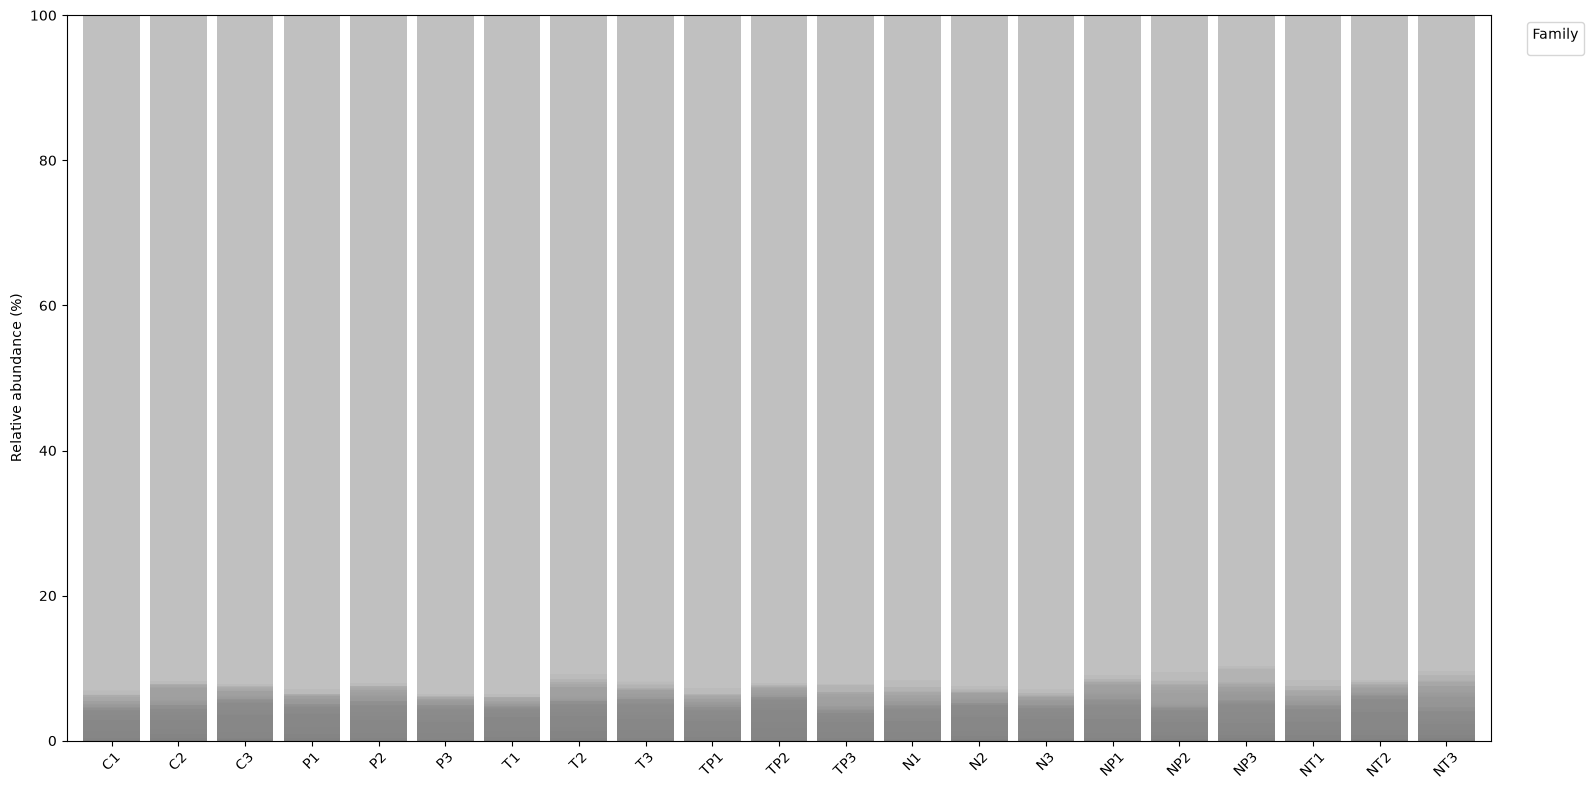

In [130]:
# Reorder species rows so stacked bars follow the requested family order
index_df = abund_df.index.to_frame(index=False)
index_df["sort_rank"] = index_df["Family"].map(family_rank).fillna(len(family_order)).astype(int)
index_df = index_df.sort_values(["sort_rank", "Family", "Genus", "Species"], kind="stable")
ordered_index = pd.MultiIndex.from_frame(index_df[["Family", "Genus", "Species"]])
species_abund_df_ordered = abund_df.loc[ordered_index]

# Default colors: same family hue, different shade within family
default_color_map = {}
for family_name, group in index_df.groupby("Family", sort=False):
    base_color = family_colors.get(family_name, "gray")
    shades = make_family_shades(base_color, len(group))
    for (_, row), shade in zip(group.iterrows(), shades):
        default_color_map[(row["Family"], row["Genus"], row["Species"])] = shade

# Special overrides requested by user
providencia_count = index_df["Genus"].astype(str).str.lower().str.startswith("providencia").sum()
providencia_shades = iter(make_color_gradient("#c4a484", "#654321", providencia_count))

species_colors = []
for _, row in index_df.iterrows():
    family_name = row["Family"]
    genus_name = str(row["Genus"]).strip().lower()
    species_name = str(row["Species"]).strip().lower()
    key = (row["Family"], row["Genus"], row["Species"])
    if genus_name.startswith("arsenophonus") and species_name == "apicola":
        color = "black"
    elif genus_name.startswith("proteus"):
        color = "#c4a484"  # light brown
    elif genus_name.startswith("providencia"):
        color = next(providencia_shades)
    else:
        color = default_color_map.get(key, family_colors.get(family_name, "gray"))
    species_colors.append(color)

fig, ax = plt.subplots(figsize=(16, 8))
species_abund_df_ordered.T.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=species_colors,
    width=0.85,
    legend=False,
 )

ax.set_ylabel("Relative abundance (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=45)

present_families = [family for family in family_order if family in set(index_df["Family"])]
legend_handles = [
    Patch(facecolor=family_colors.get(family, "gray"), label=family)
    for family in present_families
]
ax.legend(handles=legend_handles, title="Family", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
png_fp = result_dp / "taxonomy_relative_abundance_biplot.png"
fig.savefig(png_fp, dpi=300, bbox_inches="tight")
plt.show()

### PCA

Saved PCA biplot to: ../results/use-cases/bee-gut/taxonomy_pca_biplot.png


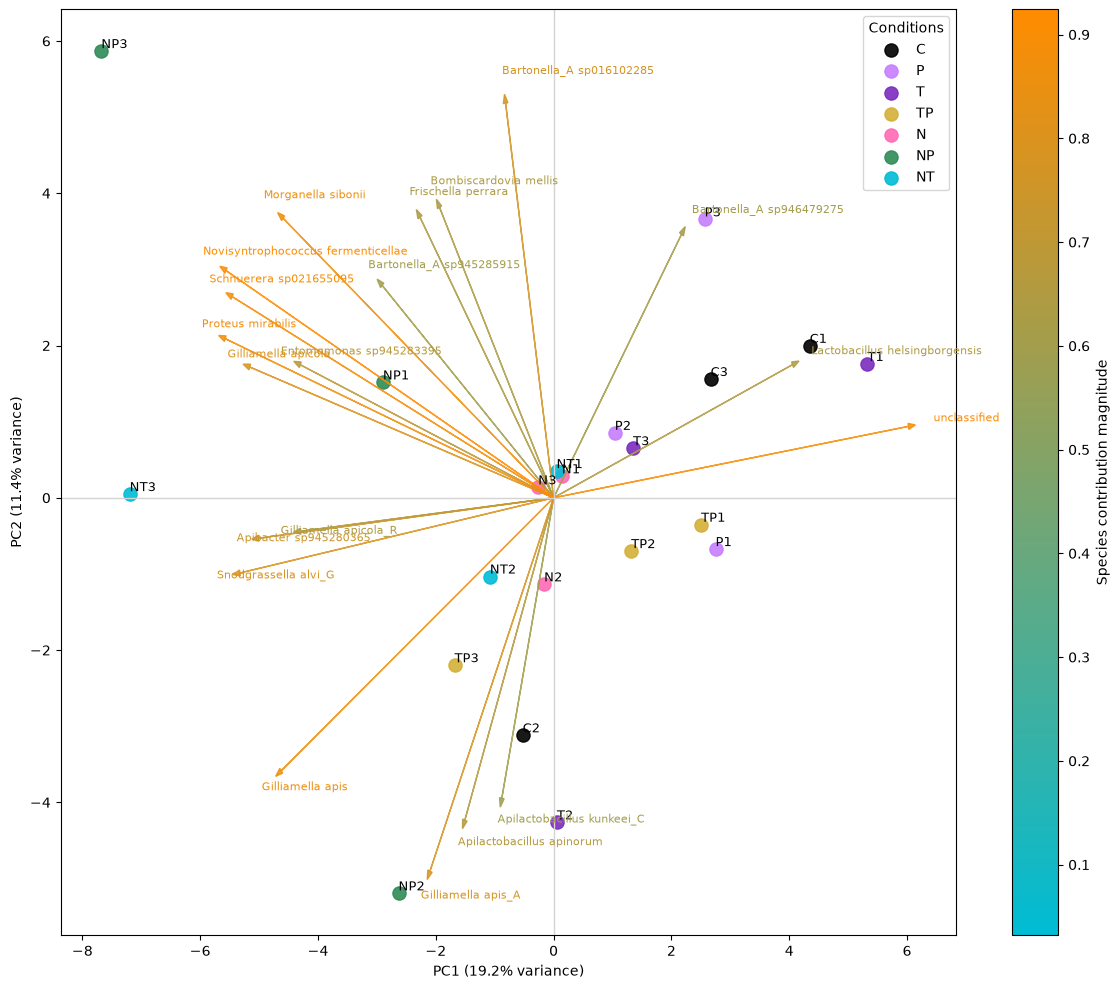

,PC1,PC2,Category
C1,4.347807,1.996067,C
C2,-0.524351,-3.119340,C
C3,2.665881,1.559212,C
P1,2.749244,-0.673502,P
P2,1.038838,0.852996,P
P3,2.564028,3.656328,P
T1,5.328596,1.758385,T
T2,0.056424,-4.263054,T
T3,1.348862,0.651178,T
TP1,2.504660,-0.353343,TP


In [131]:
sample_matrix = abund_df.select_dtypes(include=[np.number]).T

scaled_sample_matrix = StandardScaler().fit_transform(sample_matrix)
pca = PCA(n_components=2)
sample_scores = pca.fit_transform(scaled_sample_matrix)
species_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

sample_scores_df = pd.DataFrame(sample_scores, index=sample_matrix.index, columns=["PC1", "PC2"])
sample_scores_df["Category"] = (
    sample_scores_df.index.to_series()
    .str.extract(r"^(NT|NP|TP|C|T|P|N)", expand=False)
    .fillna("Other")
)

species_contribution = np.linalg.norm(species_loadings, axis=1)
contribution_norm = plt.Normalize(species_contribution.min(), species_contribution.max())
arrow_cmap = LinearSegmentedColormap.from_list("cyan_orange", ["#00bcd4", "#ff8c00"])
arrow_colors = arrow_cmap(contribution_norm(species_contribution))

top_species_idx = np.argsort(species_contribution)[-20:]
score_limit = np.abs(sample_scores_df[["PC1", "PC2"]].to_numpy()).max()
loading_limit = np.abs(species_loadings[top_species_idx]).max()
arrow_scale = 1.0 if loading_limit == 0 else (score_limit / loading_limit) * 0.8

fig, ax = plt.subplots(figsize=(12, 10))

for category, frame in sample_scores_df.groupby("Category", sort=False):
    ax.scatter(
        frame["PC1"],
        frame["PC2"],
        s=90,
        color=category_palette.get(category, category_palette["Other"]),
        label=category,
        alpha=0.9,
    )
    for sample_name, row in frame.iterrows():
        ax.text(row["PC1"], row["PC2"], sample_name, fontsize=9, ha="left", va="bottom")

for idx in top_species_idx:
    species_name = abund_df.index[idx][2]
    x_loading = species_loadings[idx, 0] * arrow_scale
    y_loading = species_loadings[idx, 1] * arrow_scale
    ax.arrow(
        0,
        0,
        x_loading,
        y_loading,
        color=arrow_colors[idx],
        alpha=0.85,
        width=0.002,
        head_width=0.08,
        length_includes_head=True,
    )
    ax.text(x_loading * 1.05, y_loading * 1.05, species_name, color=arrow_colors[idx], fontsize=8)

explained_variance = pca.explained_variance_ratio_ * 100
ax.axhline(0, color="lightgray", linewidth=1)
ax.axvline(0, color="lightgray", linewidth=1)
ax.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)")
ax.legend(title="Conditions")

sm = plt.cm.ScalarMappable(cmap=arrow_cmap, norm=contribution_norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Species contribution magnitude")

plt.tight_layout()
png_fp = result_dp / "taxonomy_pca_biplot.png"
fig.savefig(png_fp, dpi=300, bbox_inches="tight")
print(f"Saved PCA biplot to: {png_fp}")
plt.show()

sample_scores_df

## Comparison of MAGs taxonomy with original study

In [132]:
count = df_expert[
    df_expert["Origin"].astype(str).str.contains("Built MAG", na=False)
    & (df_expert["Differences between NCBI and GTDB taxonomies"] == "Yes")].shape[0]
print(f"Number of MAGs with differences between NCBI and GTDB taxonomies: {count}")

Number of MAGs with differences between NCBI and GTDB taxonomies: 20


### Statistics for MAGs origin

In [133]:
origin_df = df_expert["Origin"].value_counts(dropna=False).to_frame("count")
origin_df

,count
Origin,
"Built MAG, Species listed in the paper",19
Built MAG,19
Species listed in the paper,10


### Species identified by MAGs

#### Concordant = corresponding to species listed in the paper 

In [134]:
concordant_mags = df_expert.query("Origin == 'Built MAG, Species listed in the paper' and Species.notna()")
concordant_mags

,Name,Domain,Phylum,Class,Order,Family,Genus,Species,Species found in the paper,Differences between NCBI and GTDB taxonomies,...,Origin,Expected in such environment?,Microbiota type,Comment,Expert name,Species-level MAG count,Completeness,Contamination,Genome Size,GC Content
0,SRR24759604_bin_107333,Bacteria,Actinomycetota,Actinomycetes,Actinomycetales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium indicum,Bifidobacterium coryneforme,Yes,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper (Figure ?),NaN,8.0,96.81,2.42,1882718.0,0.61
2,SRR24759612_bin_52183,Bacteria,Bacillota,Bacilli,Bacillales_D,Amphibacillaceae,Virgibacillus,Virgibacillus proomii_B,Virgibacillus proomii,Yes,...,"Built MAG, Species listed in the paper",Yes,Non-core,listed in the paper as Virgibacillus proomis (...,NaN,1.0,99.85,0.99,4560752.0,0.36
4,SRR24759605_bin_65734,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Apilactobacillus,Apilactobacillus apinorum,Apilactobacillus apinorum,No,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 2),NaN,4.0,75.77,1.20,1054200.0,0.34
5,SRR24759606_bin_54634,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Apilactobacillus,Apilactobacillus kunkeei_C,Apilactobacillus kunkeei,Yes,...,"Built MAG, Species listed in the paper",Yes,Non-core,NaN,NaN,15.0,98.66,1.47,1404564.0,0.37
6,SRR24759613_bin_56459,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Bombilactobacillus,Bombilactobacillus mellis,Bombilactobacillus mellis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,4.0,85.51,0.83,1473654.0,0.37
8,SRR24759613_bin_39911,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Fructobacillus,Fructobacillus fructosus,Fructobacillus fructosus,No,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 2),NaN,17.0,97.52,0.23,1276613.0,0.45
9,SRR24759604_bin_148146,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus apis,Lactobacillus apis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,1.0,75.44,2.08,1396370.0,0.37
10,SRR24759603_bin_355,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus helsingborgensis,Lactobacillus helsingborgensis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,6.0,83.57,2.45,1543830.0,0.37
11,SRR24759616_bin_28305,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus melliventris,Lactobacillus melliventris,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,3.0,77.35,3.09,1403520.0,0.36
16,SRR24759613_bin_105744,Bacteria,Bacillota_A,Clostridia,Lachnospirales,Lachnospiraceae,Novisyntrophococcus,Novisyntrophococcus liquoris,Blautia liquoris,Yes,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 4),NaN,9.0,98.77,0.13,3595826.0,0.42


In [135]:
concordant_mags[["Completeness", "Contamination", "Genome Size"]].describe()

,Completeness,Contamination,Genome Size
count,19.000000,19.000000,1.900000e+01
mean,89.672632,1.898421,2.436661e+06
std,10.374308,2.317871,1.258594e+06
min,75.030000,0.050000,1.054200e+06
25%,78.005000,0.220000,1.439109e+06
50%,95.790000,1.200000,2.035396e+06
75%,99.170000,2.435000,3.357385e+06
max,100.000000,9.790000,5.438933e+06


#### Non concordant = NOT corresponding to species listed in the paper

In [136]:
non_concordant_mags = df_expert.query("Origin == 'Built MAG' and Species.notna()")
non_concordant_mags

,Name,Domain,Phylum,Class,Order,Family,Genus,Species,Species found in the paper,Differences between NCBI and GTDB taxonomies,...,Origin,Expected in such environment?,Microbiota type,Comment,Expert name,Species-level MAG count,Completeness,Contamination,Genome Size,GC Content
3,SRR24759610_bin_19,Bacteria,Bacillota,Bacilli,Lactobacillales,Enterococcaceae,Enterococcus,Enterococcus faecalis,NaN,No,...,Built MAG,NaN,NaN,No mention in the paper,NaN,7.0,99.53,0.39,2744679.0,0.38
17,SRR24759600_bin_132439,Bacteria,Bacillota_A,Clostridia,Tissierellales,Tepidimicrobiaceae,Schnuerera,Schnuerera sp021655095,NaN,Yes,...,Built MAG,NaN,NaN,No mention in the paper.,NaN,1.0,99.64,0.55,2747383.0,0.31
18,SRR24759600_bin_66323,Bacteria,Bacteroidota,Bacteroidia,Flavobacteriales,Weeksellaceae,Apibacter,Apibacter sp945280365,NaN,Yes,...,Built MAG,NaN,NaN,Taxonomy issue?,NaN,6.0,99.89,0.05,2514634.0,0.30
22,SRR24759600_bin_138516,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Bartonella_A,Bartonella_A choladocola,NaN,Yes,...,Built MAG,NaN,Non-core,NaN,NaN,2.0,87.71,1.61,1731863.0,0.46
23,SRR24759613_bin_38453,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Bartonella_A,Bartonella_A sp945285915,NaN,Yes,...,Built MAG,NaN,NaN,Correspond to Bartonella api?,NaN,1.0,88.24,1.45,2140910.0,0.42
26,SRR24759605_bin_35353,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Arsenophonus,Arsenophonus apicola,NaN,No,...,Built MAG,NaN,NaN,But Arsenophonus spp listed in the paper,NaN,1.0,99.99,0.70,3251563.0,0.37
30,SRR24759607_bin_27236,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella apicola_N,NaN,Yes,...,Built MAG,NaN,NaN,same as above?,NaN,1.0,78.78,7.15,2195362.0,0.34
31,SRR24759615_bin_55433,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella apicola_R,NaN,Yes,...,Built MAG,NaN,NaN,same as above?,NaN,1.0,75.72,6.96,2390088.0,0.35
33,SRR24759598_bin_119213,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella sp945271295,NaN,Yes,...,Built MAG,NaN,NaN,Taxonomy issue?,NaN,3.0,85.98,0.91,2504613.0,0.34
38,SRR24759602_bin_50685,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia rettgeri,NaN,Yes,...,Built MAG,NaN,NaN,But Providencia spp. listed in the paper,NaN,1.0,87.11,7.31,4418213.0,0.40


In [137]:
non_concordant_mags[["Completeness", "Contamination", "Genome Size"]].describe()

,Completeness,Contamination,Genome Size
count,13.000000,13.000000,1.300000e+01
mean,91.373077,2.381538,2.969065e+06
std,8.858552,2.769485,1.066318e+06
min,75.720000,0.050000,1.731863e+06
25%,85.980000,0.550000,2.246952e+06
50%,88.240000,1.450000,2.514634e+06
75%,99.890000,1.810000,3.251563e+06
max,100.000000,7.310000,5.131086e+06


#### Comparison of completess and contamination between concordant and non-concordant species

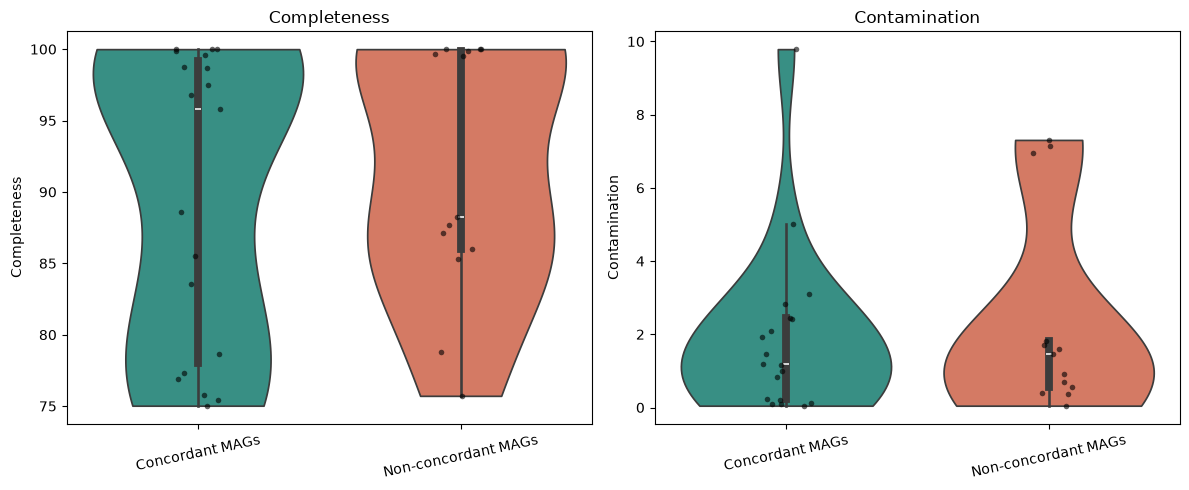

In [138]:
metrics = ["Completeness", "Contamination"]
group_order = ["Concordant MAGs", "Non-concordant MAGs"]

plot_frames = []
for group_name, frame in [
    ("Concordant MAGs", concordant_mags),
    ("Non-concordant MAGs", non_concordant_mags),
]:
    subset = frame[metrics].copy()
    for metric in metrics:
        subset[metric] = pd.to_numeric(subset[metric], errors="coerce")
    subset["Group"] = group_name
    plot_frames.append(subset)

plot_df = pd.concat(plot_frames, ignore_index=True)

palette = {
    "Concordant MAGs": "#2a9d8f",
    "Non-concordant MAGs": "#e76f51",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, metrics):
    sns.violinplot(
        data=plot_df,
        x="Group",
        y=metric,
        hue="Group",
        order=group_order,
        hue_order=group_order,
        palette=palette,
        cut=0,
        inner="box",
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=plot_df,
        x="Group",
        y=metric,
        order=group_order,
        color="black",
        alpha=0.6,
        size=4,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=12)

plt.tight_layout()
plt.show()